# QSVT Polynomial Design and Approximation

QSVT polynomial design replaces hand-picked transforms with systematic
bounded approximations to target functions.

Earlier notebooks used hand-picked polynomials:

- f(x) = x²
- f(x) = x
- f(x) = x³
- T₃(x) = 4x³ − 3x

The design workflow constructs bounded polynomials for useful target
functions.

## Variable definitions

- $x\in[-1,1]$ is the normalized scalar or eigenvalue being transformed.
- $f(x)$ is the desired target function, and $P(x)$ is its bounded polynomial approximation.
- $T_n(x)=\cos(n\arccos x)$ is the degree-$n$ Chebyshev polynomial, with $n$ a non-negative integer.
- $\lambda$ denotes an eigenvalue of the normalized operator.
- $a\in(0,1)$ is the lower spectral-gap bound in $|\lambda|\ge a$.
- `degree` is the maximum polynomial degree used by the approximation builder.

## Notebook guide

- **Learning objective:** design Chebyshev approximations and measure their error.
- **Prerequisites:** an editable repository install plus basic NumPy and linear-algebra familiarity.
- **Estimated runtime:** about 1–3 minutes on a local CPU.
- **Navigation:** [collection index](README.md) · [previous](04_QSVT_Exact_Linear_Solver_Toy_Cases.ipynb) · [next](06_QSVT_Matrix_Functions_Powers_and_Roots.ipynb).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qsvt.design import design_inverse_polynomial
from qsvt.polynomials import (
    chebyshev_t,
    eval_polynomial,
)

from qsvt.approximation import (
    chebyshev_fit_function,
    max_error,
)

## 1. Why QSVT uses polynomials

QSVT implements polynomial transformations because quantum circuits
are unitary and therefore bounded.

Any admissible function must satisfy:

|f(x)| ≤ 1  for x in [-1,1].

Therefore many useful functions must be approximated by bounded polynomials.

## 2. Chebyshev polynomials

Chebyshev polynomials satisfy:

T_n(x) = cos(n arccos x)

and obey:

|T_n(x)| ≤ 1   on [-1,1]

making them natural building blocks for QSVT polynomials.

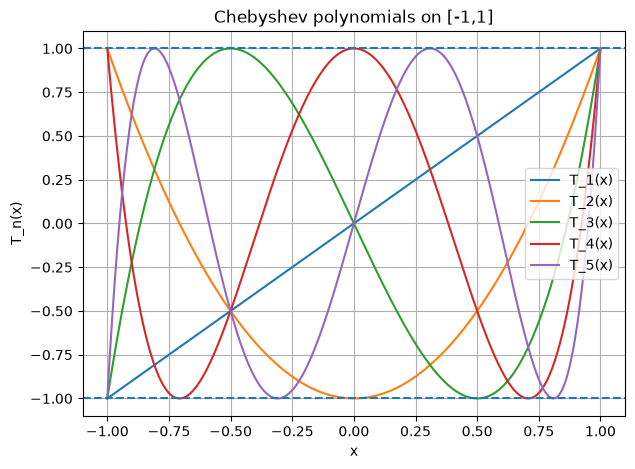

In [2]:
x = np.linspace(-1, 1, 400)

plt.figure(figsize=(7, 5))

for n in [1, 2, 3, 4, 5]:
    plt.plot(x, chebyshev_t(n, x), label=f"T_{n}(x)")

plt.axhline(1, linestyle="--")
plt.axhline(-1, linestyle="--")

plt.title("Chebyshev polynomials on [-1,1]")
plt.xlabel("x")
plt.ylabel("T_n(x)")

plt.grid(True)
plt.legend()

plt.show()

## 3. Approximating inverse-like behaviour

The inverse function 1/x is unbounded near zero.

If eigenvalues satisfy:

|λ| ≥ a > 0

the approximation domain excludes the gap around zero:

[-1,-a] ∪ [a,1]

which allows bounded polynomial approximations.

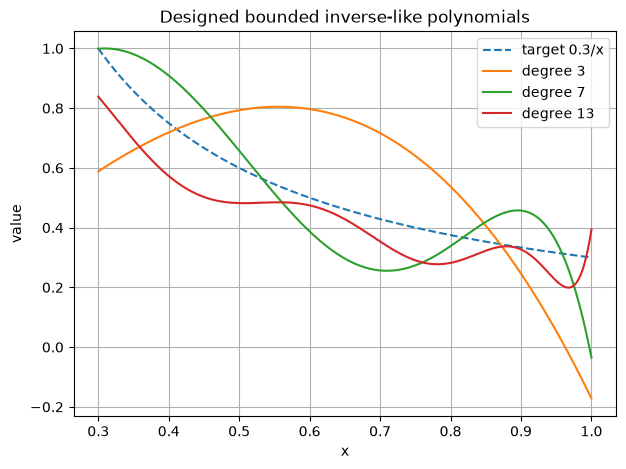

In [3]:
a = 0.3


def scaled_inv(x):
    return a / x


xs = np.linspace(a, 1.0, 400)

plt.figure(figsize=(7, 5))
plt.plot(xs, scaled_inv(xs), "--", label=f"target {a}/x")

for deg in [3, 7, 13]:
    coeffs = design_inverse_polynomial(gamma=a, degree=deg)
    approx = eval_polynomial(coeffs, xs)
    plt.plot(xs, approx, label=f"degree {deg}")

plt.title("Designed bounded inverse-like polynomials")
plt.xlabel("x")
plt.ylabel("value")
plt.grid(True)
plt.legend()
plt.show()

## 4. Approximation error vs degree

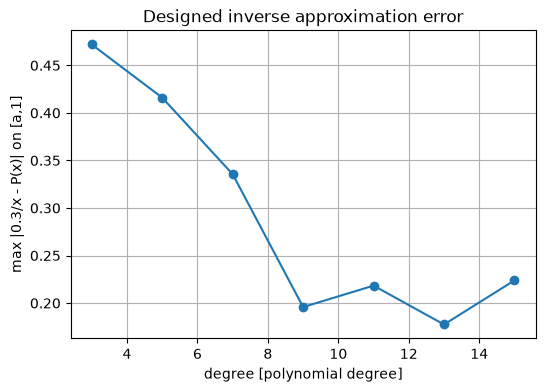

In [4]:
degrees = [3, 5, 7, 9, 11, 13, 15]
errors = []
bounded_maxima = []

for deg in degrees:
    coeffs = design_inverse_polynomial(gamma=a, degree=deg)

    x_bound = np.linspace(-1.0, 1.0, 2001)
    vals_bound = eval_polynomial(coeffs, x_bound)
    bounded_maxima.append(float(np.max(np.abs(vals_bound))))

    def approx_fn(x, coeffs=coeffs):
        return eval_polynomial(coeffs, x)

    err = max_error(
        scaled_inv,
        approx_fn,
        domain=(a, 1.0),
        num_points=1000,
    )
    errors.append(err)

best_error = min(errors)
best_degree = degrees[int(np.argmin(errors))]

plt.figure(figsize=(6, 4))
plt.plot(degrees, errors, "o-")
plt.xlabel("degree [polynomial degree]")
plt.ylabel(f"max |{a}/x - P(x)| on [a,1]")
plt.title("Designed inverse approximation error")
plt.grid(True)
plt.show()

The error is not guaranteed to decrease monotonically for this lightweight educational fitter, but the design helper keeps the polynomial bounded while producing useful inverse-like behavior on the safe spectral interval.


## Summary

QSVT works by implementing bounded polynomial transformations.

Chebyshev polynomials provide:

- boundedness on [-1,1]
- efficient approximation properties
- controlled tradeoff between degree and accuracy

Polynomial design is therefore central to practical QSVT algorithms.

## Validation

Compact checks for the expected tutorial behavior.


In [5]:
assert all(maximum <= 1.0 + 1e-8 for maximum in bounded_maxima)
assert best_error < 0.2
assert errors[0] > best_error

print(f"best_degree [polynomial degree]: {best_degree}")
print(f"best_inverse_error: {best_error:.3e}")
print(f"max_bounded_value: {max(bounded_maxima):.6f}")
print("validation: passed")

best_degree [polynomial degree]: 13
best_inverse_error: 1.775e-01
max_bounded_value: 0.999999
validation: passed


## Takeaways and next steps

- **Result:** The workflow shows how to design Chebyshev approximations and measure their error.
- **Interpretation boundary:** Treat simulator-scale circuits and resource proxies according to the truth contract stated in the notebook.
- **Continue:** [collection index](README.md) · [previous](04_QSVT_Exact_Linear_Solver_Toy_Cases.ipynb) · [next](06_QSVT_Matrix_Functions_Powers_and_Roots.ipynb).
